# Squat Exercise — GCN Training Notebook

One model trained end-to-end:
- **Stage detector** — 3 classes: `up`, `middle`, `down`

Architecture: 3-layer GCNConv → flatten → FC head (same pattern as plank, bicep & lunge GCNs).

> **Dataset columns** (36 features + label):
> `label | nose | left_shoulder | right_shoulder | left_hip | right_hip | left_knee | right_knee | left_ankle | right_ankle`
> Each landmark contributes 4 features: `_x`, `_y`, `_z`, `_v` (visibility).


In [5]:
!pip install torch_geometric

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
import pickle
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    precision_recall_fscore_support,
)

# ── Reproducibility ───────────────────────────────────────────
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
C1, C2, C3, C4 = "#667eea", "#f093fb", "#4facfe", "#43e97b"

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 12,
    "axes.titlesize": 14, "axes.labelsize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
})

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
print(f"CUDA    : {torch.cuda.is_available()}")


PyTorch : 2.10.0+cu128
Device  : cuda
CUDA    : True


---
## 1. Graph Structure — 9-Node Squat Skeleton

Squats use 9 landmarks from the CSV: nose + shoulders + hips + knees + ankles.
This is the minimal chain needed to capture torso angle, hip depth and knee tracking.
Cross-hip edges capture bilateral symmetry — essential for detecting knee caving.


In [7]:
# ── Landmark order — matches CSV column order exactly ─────────────────────
LANDMARKS = [
    "nose",
    "left_shoulder",  "right_shoulder",
    "left_hip",       "right_hip",
    "left_knee",      "right_knee",
    "left_ankle",     "right_ankle",
]
N_NODES = len(LANDMARKS)   # 9
N_FEATS = 4                # x, y, z, visibility

# Anatomical edges — kinematic chain from head to feet
SKELETON_EDGES = [
    # Head → torso
    ("nose",          "left_shoulder"),
    ("nose",          "right_shoulder"),
    # Collar
    ("left_shoulder", "right_shoulder"),
    # Trunk
    ("left_shoulder", "left_hip"),
    ("right_shoulder","right_hip"),
    ("left_hip",      "right_hip"),
    # Legs
    ("left_hip",      "left_knee"),
    ("right_hip",     "right_knee"),
    ("left_knee",     "left_ankle"),
    ("right_knee",    "right_ankle"),
    # Cross-knee (captures knee cave / valgus in squat)
    ("left_hip",      "right_knee"),
    ("right_hip",     "left_knee"),
    # Ankles connected (foot width context)
    ("left_ankle",    "right_ankle"),
]

node_to_idx = {n: i for i, n in enumerate(LANDMARKS)}

# Bidirectional edge_index
src, dst = [], []
for u, v in SKELETON_EDGES:
    i, j = node_to_idx[u], node_to_idx[v]
    src += [i, j]
    dst += [j, i]
EDGE_INDEX = torch.tensor([src, dst], dtype=torch.long)

print(f"Nodes : {N_NODES}")
print(f"Edges : {len(SKELETON_EDGES)} undirected → {EDGE_INDEX.shape[1]} directed")
print(f"edge_index shape : {EDGE_INDEX.shape}")
print("\nLandmark → node index:")
for name, idx in node_to_idx.items():
    print(f"  {idx:2d}: {name}")


Nodes : 9
Edges : 13 undirected → 26 directed
edge_index shape : torch.Size([2, 26])

Landmark → node index:
   0: nose
   1: left_shoulder
   2: right_shoulder
   3: left_hip
   4: right_hip
   5: left_knee
   6: right_knee
   7: left_ankle
   8: right_ankle


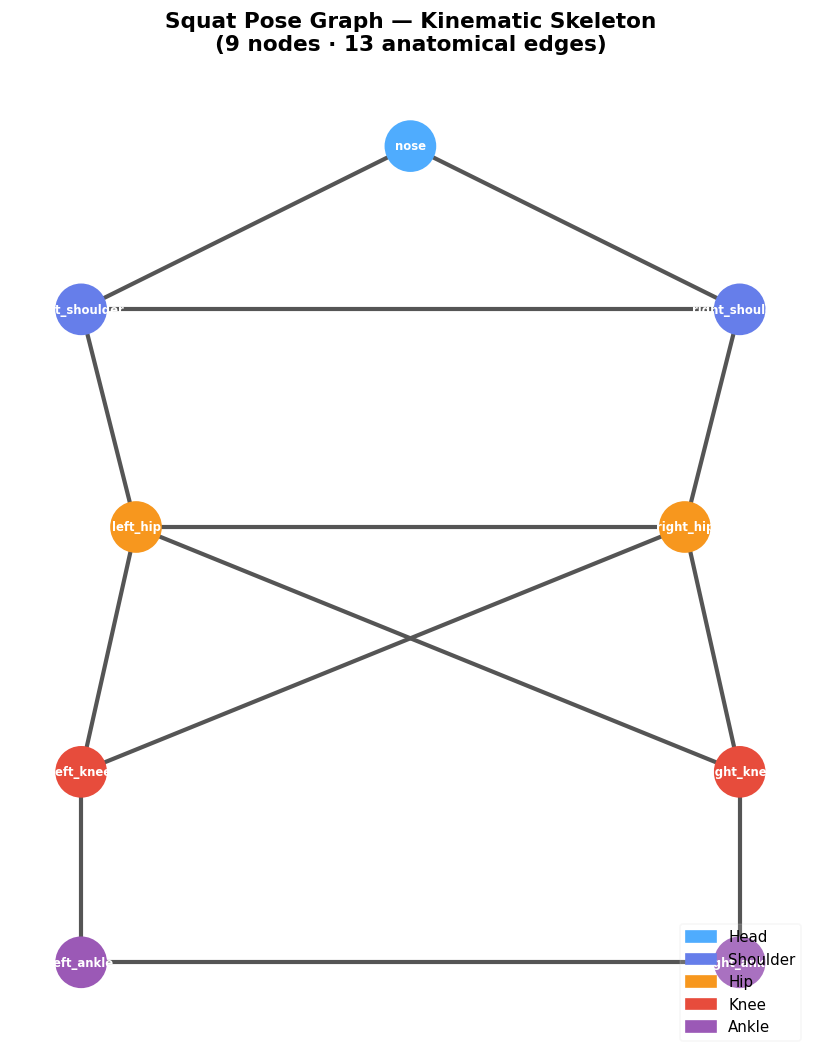

Saved: fig_01_squat_pose_graph.png


In [8]:
# ── Visualise the squat skeleton graph ────────────────────────────────────
G = nx.Graph()
G.add_nodes_from(LANDMARKS)
G.add_edges_from(SKELETON_EDGES)

# Anatomical layout — upright squat position (symmetric stance)
pos = {
    "nose":            ( 0.0,  3.0),
    "left_shoulder":   (-0.6,  2.4),  "right_shoulder":  ( 0.6,  2.4),
    "left_hip":        (-0.5,  1.6),  "right_hip":       ( 0.5,  1.6),
    "left_knee":       (-0.6,  0.7),  "right_knee":      ( 0.6,  0.7),
    "left_ankle":      (-0.6,  0.0),  "right_ankle":     ( 0.6,  0.0),
}

node_color_map = {
    "nose"          : C3,
    "left_shoulder" : C1,  "right_shoulder" : C1,
    "left_hip"      : "#f7971e", "right_hip"      : "#f7971e",
    "left_knee"     : "#e74c3c", "right_knee"     : "#e74c3c",
    "left_ankle"    : "#9b59b6", "right_ankle"    : "#9b59b6",
}
node_colors = [node_color_map[n] for n in LANDMARKS]

fig, ax = plt.subplots(figsize=(7, 9))
nx.draw_networkx_edges(G, pos, width=2.5, edge_color="#555", ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_color="white",
                        font_weight="bold", ax=ax)
legend_items = [
    mpatches.Patch(color=C3,        label="Head"),
    mpatches.Patch(color=C1,        label="Shoulder"),
    mpatches.Patch(color="#f7971e", label="Hip"),
    mpatches.Patch(color="#e74c3c", label="Knee"),
    mpatches.Patch(color="#9b59b6", label="Ankle"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=9, framealpha=0.15)
ax.set_title(
    "Squat Pose Graph — Kinematic Skeleton\n"
    f"(9 nodes · {len(SKELETON_EDGES)} anatomical edges)",
    fontsize=13, fontweight="bold"
)
ax.axis("off")
plt.tight_layout()
plt.savefig("fig_01_squat_pose_graph.png", bbox_inches="tight")
plt.show()
print("Saved: fig_01_squat_pose_graph.png")


---
## 2. Shared Utilities

Pose normalisation, dataset builder, model class, training/evaluation loops — defined once and reused.


In [9]:
# ── Camera-invariant pose normalisation ──────────────────────────────────
def normalize_pose(df):
    """
    1. Subtract torso centre  → removes camera position offset
    2. Divide by torso size   → removes camera distance / body height
    Operates on all x/y/z columns; visibility is left unchanged.
    """
    df = df.copy()

    centre_x = (df["left_shoulder_x"] + df["right_shoulder_x"] +
                 df["left_hip_x"]      + df["right_hip_x"]) / 4
    centre_y = (df["left_shoulder_y"] + df["right_shoulder_y"] +
                 df["left_hip_y"]      + df["right_hip_y"]) / 4

    shoulder_mid_x = (df["left_shoulder_x"] + df["right_shoulder_x"]) / 2
    shoulder_mid_y = (df["left_shoulder_y"] + df["right_shoulder_y"]) / 2
    hip_mid_x      = (df["left_hip_x"]      + df["right_hip_x"])      / 2
    hip_mid_y      = (df["left_hip_y"]      + df["right_hip_y"])      / 2

    torso_size = np.sqrt(
        (shoulder_mid_x - hip_mid_x) ** 2 +
        (shoulder_mid_y - hip_mid_y) ** 2
    ) + 1e-6

    for lm in LANDMARKS:
        df[f"{lm}_x"] = (df[f"{lm}_x"] - centre_x) / torso_size
        df[f"{lm}_y"] = (df[f"{lm}_y"] - centre_y) / torso_size
        df[f"{lm}_z"] =  df[f"{lm}_z"]              / torso_size
        # visibility unchanged

    return df


In [10]:
# ── Graph dataset builder ─────────────────────────────────────────────────
def build_graph_dataset(X_np, y_np, edge_index):
    """Convert flat [N, N_NODES*N_FEATS] array into PyG Data list."""
    dataset = []
    for i in range(len(X_np)):
        x = torch.tensor(X_np[i].reshape(N_NODES, N_FEATS), dtype=torch.float)
        y = torch.tensor(y_np[i], dtype=torch.long)
        dataset.append(Data(x=x, edge_index=edge_index, y=y))
    return dataset


In [11]:
# ── SquatGCN — 3-layer GCN with flatten head ─────────────────────────────
class SquatGCN(nn.Module):
    """
    3-layer GCNConv → flatten → FC classification head.
    Flatten (not global_mean_pool) preserves node identity,
    which is critical for a fixed-size pose graph.

    For stage : n_classes=3  (down, middle, up)

    Flatten head input: 9 nodes × 32 out_feats = 288
    """
    def __init__(self, in_feats=4, hidden=64, out_feats=32,
                 n_classes=3, dropout=0.4):
        super().__init__()
        self.out_feats = out_feats

        self.conv1 = GCNConv(in_feats, hidden)
        self.conv2 = GCNConv(hidden,   hidden)
        self.conv3 = GCNConv(hidden,   out_feats)

        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.bn3 = nn.BatchNorm1d(out_feats)

        # 9 × 32 = 288
        self.head = nn.Sequential(
            nn.Linear(N_NODES * out_feats, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn3(self.conv3(x, edge_index)))

        # Flatten — preserves all 9 node embeddings separately
        batch_size = batch.max().item() + 1
        x = x.view(batch_size, N_NODES * self.out_feats)   # [B, 288]

        return self.head(x)

    def embed(self, data):
        """Return flattened node embeddings (before head) for visualisation."""
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        batch_size = batch.max().item() + 1
        return x.view(batch_size, N_NODES * self.out_feats)


In [12]:
# ── Training & evaluation loops ───────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        correct    += (out.argmax(1) == batch.y).sum().item()
        total      += batch.num_graphs
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_labels = [], [], []
    for batch in loader:
        batch = batch.to(device)
        out   = model(batch)
        loss  = criterion(out, batch.y)
        total_loss += loss.item() * batch.num_graphs
        probs = F.softmax(out, dim=1)
        pred  = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total   += batch.num_graphs
        all_preds.extend(pred.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_probs), np.array(all_labels))


def train_model(model, train_loader, test_loader, name="SquatGCN", epochs=120):
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_acc, best_state = 0.0, None

    print(f"Training {name} on {DEVICE} ...")
    print(f"{'Epoch':>6} {'TrainLoss':>10} {'ValLoss':>10} {'TrainAcc':>10} {'ValAcc':>10}")
    print("-" * 55)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        va_loss, va_acc, _, _, _ = evaluate(model, test_loader, criterion, DEVICE)
        scheduler.step(va_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if va_acc > best_acc:
            best_acc  = va_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f"{epoch:>6} {tr_loss:>10.4f} {va_loss:>10.4f} "
                  f"{tr_acc*100:>9.2f}% {va_acc*100:>9.2f}%")

    model.load_state_dict(best_state)
    print(f"\n✅  Best val accuracy: {best_acc*100:.2f}%")
    return history


---
## 3. Stage Detector — 3-Class (down / middle / up)

Classifies the squat phase: **down** = full depth, **middle** = transitioning, **up** = standing.

Expected CSV files: `train.csv` and `test.csv` with a `label` column containing `"down"`, `"middle"`, `"up"`.


In [15]:
# ── Load stage datasets ───────────────────────────────────────────────────
stage_train_df = pd.read_csv("train.csv")
stage_test_df  = pd.read_csv("test.csv")

stage_train_df = stage_train_df.reset_index(drop=True)
stage_test_df  = stage_test_df.reset_index(drop=True)

print(f"Stage Train : {len(stage_train_df):,} samples")
print(f"Stage Test  : {len(stage_test_df):,} samples")
print(f"\nTrain label counts:\n{stage_train_df['label'].value_counts()}")
print(f"\nTest  label counts:\n{stage_test_df['label'].value_counts()}")

# Confirm column layout
print("\nColumn names:", list(stage_train_df.columns))


Stage Train : 4,160 samples
Stage Test  : 853 samples

Train label counts:
label
down    2127
up      2033
Name: count, dtype: int64

Test  label counts:
label
down    430
up      423
Name: count, dtype: int64

Column names: ['label', 'nose_x', 'nose_y', 'nose_z', 'nose_v', 'left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z', 'left_shoulder_v', 'right_shoulder_x', 'right_shoulder_y', 'right_shoulder_z', 'right_shoulder_v', 'left_hip_x', 'left_hip_y', 'left_hip_z', 'left_hip_v', 'right_hip_x', 'right_hip_y', 'right_hip_z', 'right_hip_v', 'left_knee_x', 'left_knee_y', 'left_knee_z', 'left_knee_v', 'right_knee_x', 'right_knee_y', 'right_knee_z', 'right_knee_v', 'left_ankle_x', 'left_ankle_y', 'left_ankle_z', 'left_ankle_v', 'right_ankle_x', 'right_ankle_y', 'right_ankle_z', 'right_ankle_v']


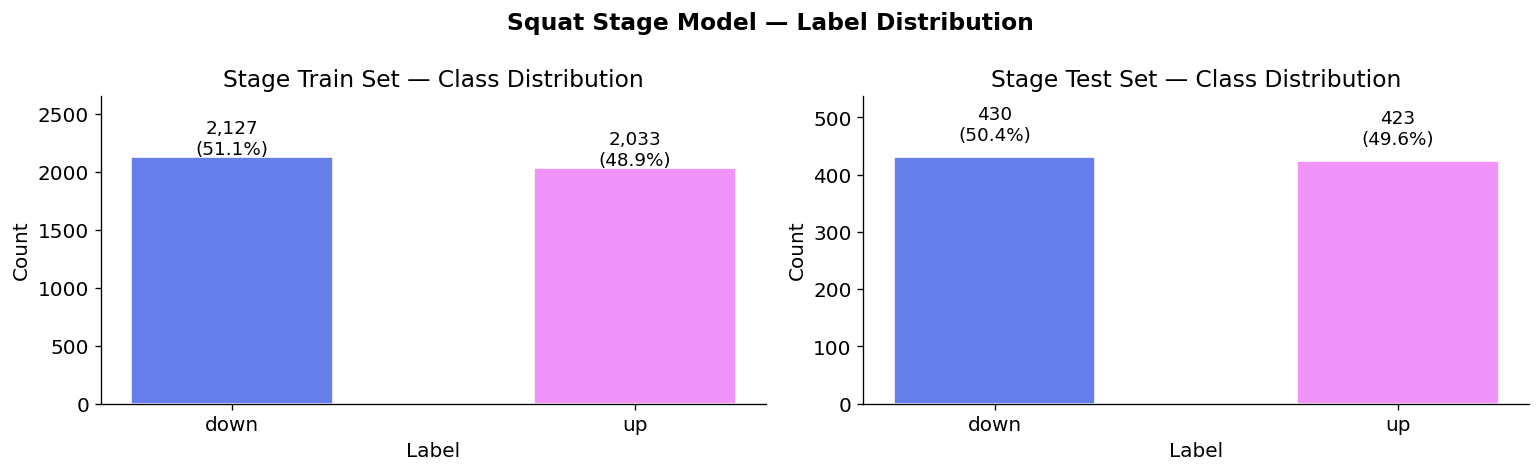

In [16]:
# ── Class distribution ───────────────────────────────────────────────────
PALETTE = [C1, C2, C3]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (df_plot, title) in zip(axes, [
        (stage_train_df, "Stage Train Set"),
        (stage_test_df,  "Stage Test Set")]):
    counts = df_plot["label"].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=PALETTE[:len(counts)], edgecolor="white", width=0.5)
    ax.set_title(f"{title} — Class Distribution")
    ax.set_xlabel("Label"); ax.set_ylabel("Count")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f"{val:,}\n({val/len(df_plot)*100:.1f}%)",
                ha="center", fontsize=11)
    ax.set_ylim(0, counts.max() * 1.25)
plt.suptitle("Squat Stage Model — Label Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_02_stage_class_distribution.png", bbox_inches="tight")
plt.show()


In [17]:
# ── Normalise + encode + scale (stage) ───────────────────────────────────
stage_train_norm = normalize_pose(stage_train_df)
stage_test_norm  = normalize_pose(stage_test_df)

stage_le = LabelEncoder()
y_stage_train = stage_le.fit_transform(stage_train_norm["label"].values)
y_stage_test  = stage_le.transform(stage_test_norm["label"].values)
N_STAGE_CLASSES = len(stage_le.classes_)

print("Stage label encoding:", dict(zip(stage_le.classes_, stage_le.transform(stage_le.classes_))))
print("Classes:", stage_le.classes_.tolist(), "| N_CLASSES:", N_STAGE_CLASSES)

# Feature columns = all except label
FEATURE_COLS = [c for c in stage_train_norm.columns if c != "label"]
print(f"\nFeature count: {len(FEATURE_COLS)}  (= {N_NODES} nodes × {N_FEATS} feats)")

# Scaler: fit on training data ONLY
stage_scaler = StandardScaler()
X_stage_train = stage_scaler.fit_transform(stage_train_norm[FEATURE_COLS].values)
X_stage_test  = stage_scaler.transform(stage_test_norm[FEATURE_COLS].values)

print(f"\nTrain — mean: {X_stage_train.mean():+.5f} | std: {X_stage_train.std():.5f}")
print(f"Test  — mean: {X_stage_test.mean():+.5f}  | std: {X_stage_test.std():.5f}")


Stage label encoding: {'down': np.int64(0), 'up': np.int64(1)}
Classes: ['down', 'up'] | N_CLASSES: 2

Feature count: 36  (= 9 nodes × 4 feats)

Train — mean: -0.00000 | std: 1.00000
Test  — mean: -0.02055  | std: 0.91193


In [18]:
# ── Build PyG datasets (stage) ────────────────────────────────────────────
BATCH_SIZE = 256

stage_train_dataset = build_graph_dataset(X_stage_train, y_stage_train, EDGE_INDEX)
stage_test_dataset  = build_graph_dataset(X_stage_test,  y_stage_test,  EDGE_INDEX)

stage_train_loader = DataLoader(stage_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
stage_test_loader  = DataLoader(stage_test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

s = stage_train_dataset[0]
print("Single graph object:")
print(f"  data.x          : {s.x.shape}    → [{N_NODES} nodes, {N_FEATS} features]")
print(f"  data.edge_index : {s.edge_index.shape}   → [2, {EDGE_INDEX.shape[1]} directed edges]")
print(f"  data.y          : {s.y.item()}")
print(f"\nTrain batches : {len(stage_train_loader)}")
print(f"Test  batches : {len(stage_test_loader)}")


Single graph object:
  data.x          : torch.Size([9, 4])    → [9 nodes, 4 features]
  data.edge_index : torch.Size([2, 26])   → [2, 26 directed edges]
  data.y          : 0

Train batches : 17
Test  batches : 4


In [19]:
# ── Instantiate Stage GCN ─────────────────────────────────────────────────
EPOCHS = 120

stage_model = SquatGCN(
    in_feats=4,
    hidden=64,
    out_feats=32,
    n_classes=N_STAGE_CLASSES,
    dropout=0.4,
).to(DEVICE)

total_params = sum(p.numel() for p in stage_model.parameters() if p.requires_grad)
print(f"Model architecture:\n{stage_model}")
print(f"\nTotal trainable parameters: {total_params:,}")
print(f"Flatten dim: {N_NODES} nodes × 32 out_feats = {N_NODES * 32}")


Model architecture:
SquatGCN(
  (conv1): GCNConv(4, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 32)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (head): Sequential(
    (0): Linear(in_features=288, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

Total trainable parameters: 52,258
Flatten dim: 9 nodes × 32 out_feats = 288


In [20]:
# ── Train Stage GCN ───────────────────────────────────────────────────────
stage_history = train_model(
    stage_model, stage_train_loader, stage_test_loader,
    name="SquatGCN-Stage", epochs=EPOCHS
)


Training SquatGCN-Stage on cuda ...
 Epoch  TrainLoss    ValLoss   TrainAcc     ValAcc
-------------------------------------------------------
     1     0.3422     0.0658     90.22%     99.77%
    10     0.0047     0.0271     99.86%     99.41%
    20     0.0031     0.0341     99.90%     99.30%
    30     0.0018     0.0454     99.98%     99.18%
    40     0.0026     0.0459     99.90%     99.18%
    50     0.0021     0.0473     99.93%     99.18%
    60     0.0012     0.0461     99.98%     99.18%
    70     0.0025     0.0462     99.90%     99.18%
    80     0.0024     0.0466     99.90%     99.18%
    90     0.0014     0.0461     99.98%     99.18%
   100     0.0050     0.0475     99.81%     99.18%
   110     0.0013     0.0472     99.95%     99.18%
   120     0.0033     0.0472     99.90%     99.18%

✅  Best val accuracy: 99.77%


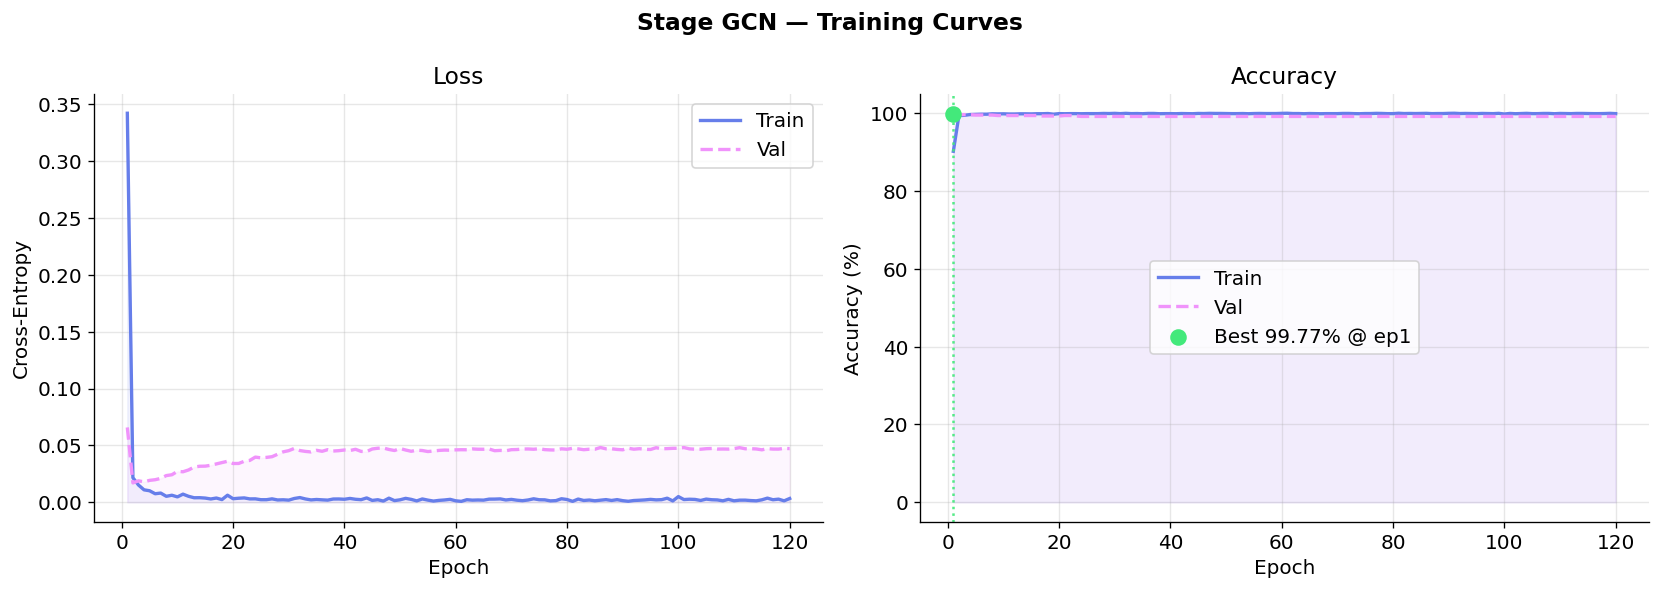

Saved: eval_stage_01_training_curves.png


In [21]:
# ── Training curves (stage) ───────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Stage GCN — Training Curves", fontsize=14, fontweight="bold")

axes[0].plot(epochs_range, stage_history["train_loss"], color=C1, lw=2, label="Train")
axes[0].plot(epochs_range, stage_history["val_loss"],   color=C2, lw=2, ls="--", label="Val")
axes[0].fill_between(epochs_range, stage_history["train_loss"], alpha=0.08, color=C1)
axes[0].fill_between(epochs_range, stage_history["val_loss"],   alpha=0.08, color=C2)
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy")
axes[0].legend()

train_acc_pct = [a*100 for a in stage_history["train_acc"]]
val_acc_pct   = [a*100 for a in stage_history["val_acc"]]
axes[1].plot(epochs_range, train_acc_pct, color=C1, lw=2, label="Train")
axes[1].plot(epochs_range, val_acc_pct,   color=C2, lw=2, ls="--", label="Val")
axes[1].fill_between(epochs_range, train_acc_pct, alpha=0.08, color=C1)
axes[1].fill_between(epochs_range, val_acc_pct,   alpha=0.08, color=C2)

best_ep  = int(np.argmax(val_acc_pct)) + 1
best_val = max(val_acc_pct)
axes[1].axvline(best_ep, color=C4, lw=1.5, ls=":", alpha=0.9)
axes[1].scatter(best_ep, best_val, color=C4, s=80, zorder=5,
                label=f"Best {best_val:.2f}% @ ep{best_ep}")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("eval_stage_01_training_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_stage_01_training_curves.png")


In [22]:
# ── Stage model evaluation on test set ───────────────────────────────────
criterion_eval = nn.CrossEntropyLoss()
_, stage_acc, stage_preds, stage_probs, stage_true = evaluate(
    stage_model, stage_test_loader, criterion_eval, DEVICE
)

stage_metrics = {
    "Accuracy" : accuracy_score(stage_true, stage_preds),
    "F1 Score" : f1_score(stage_true, stage_preds, average="macro"),
    "Precision": precision_score(stage_true, stage_preds, average="macro"),
    "Recall"   : recall_score(stage_true, stage_preds, average="macro"),
}

print("Stage GCN — Test Set Metrics:")
for k, v in stage_metrics.items():
    print(f"  {k:12s}: {v*100:.2f}%")

print("\n── Full Classification Report ──")
print(classification_report(stage_true, stage_preds,
      target_names=[f"{c}" for c in stage_le.classes_]))


Stage GCN — Test Set Metrics:
  Accuracy    : 99.77%
  F1 Score    : 99.77%
  Precision   : 99.77%
  Recall      : 99.76%

── Full Classification Report ──
              precision    recall  f1-score   support

        down       1.00      1.00      1.00       430
          up       1.00      1.00      1.00       423

    accuracy                           1.00       853
   macro avg       1.00      1.00      1.00       853
weighted avg       1.00      1.00      1.00       853



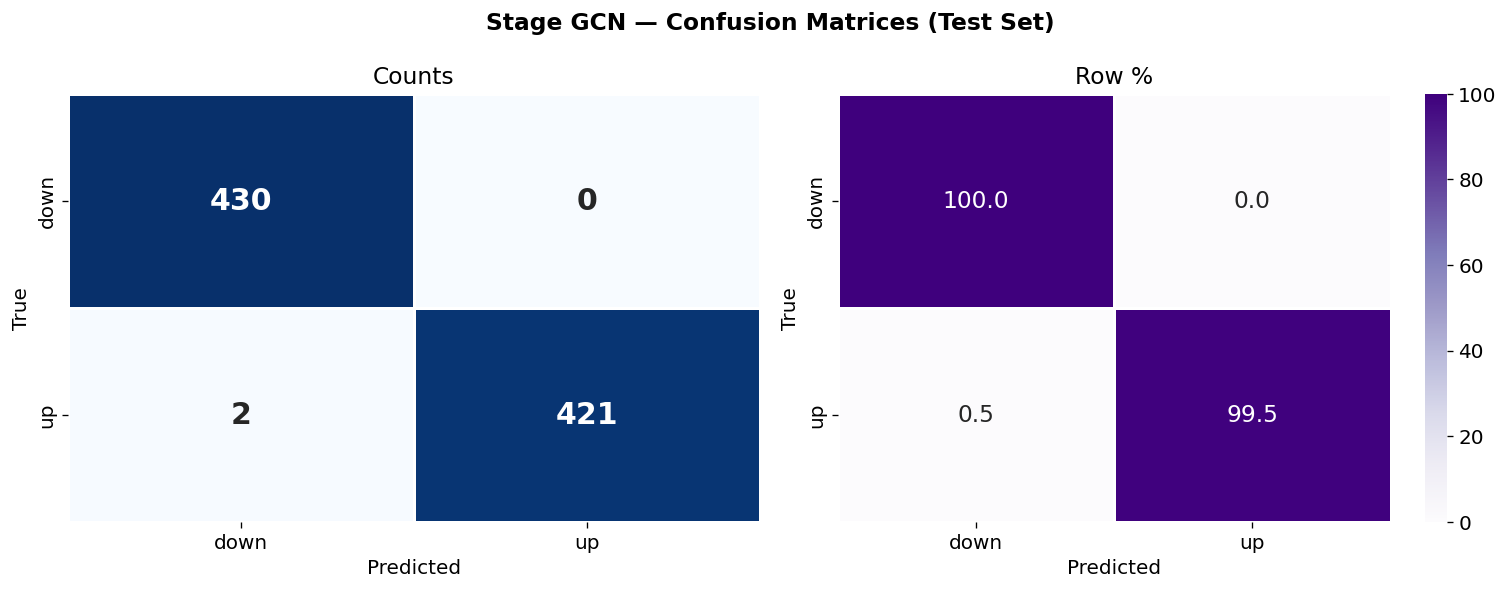

Saved: eval_stage_02_confusion_matrix.png


In [23]:
# ── Confusion matrix (stage) ──────────────────────────────────────────────
class_names = stage_le.classes_
cm     = confusion_matrix(stage_true, stage_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Stage GCN — Confusion Matrices (Test Set)", fontsize=14, fontweight="bold")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1.5, ax=axes[0], cbar=False,
            annot_kws={"size": 18, "weight": "bold"})
axes[0].set_title("Counts"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Purples",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1.5, ax=axes[1], cbar=True,
            annot_kws={"size": 14})
axes[1].set_title("Row %"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("eval_stage_02_confusion_matrix.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_stage_02_confusion_matrix.png")


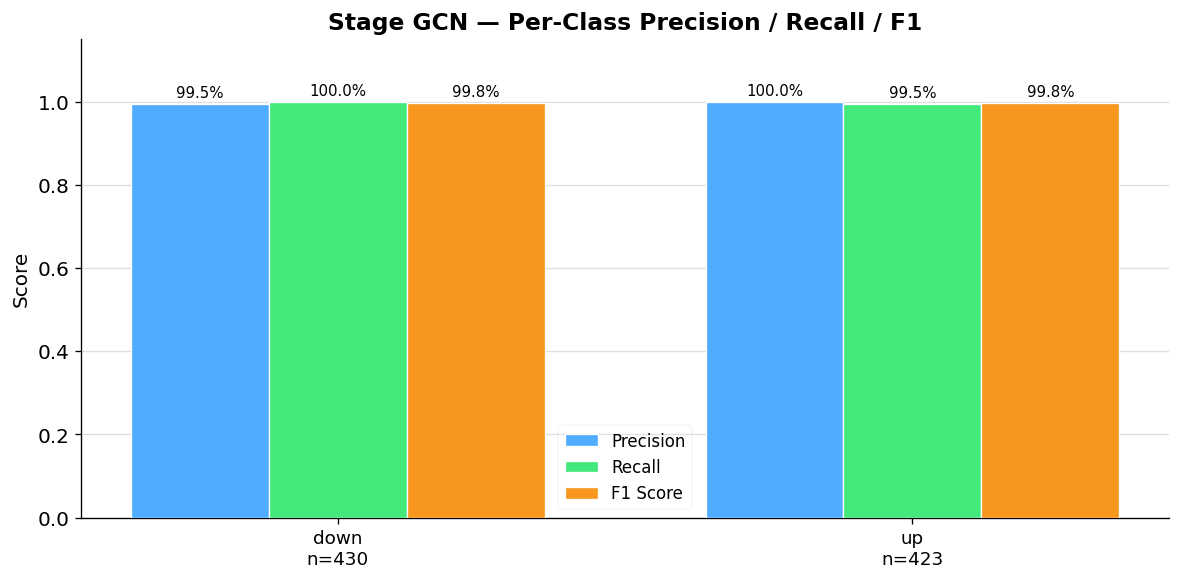

Saved: eval_stage_03_per_class_metrics.png


In [24]:
# ── Per-class Precision / Recall / F1 (stage) ────────────────────────────
prec, rec, f1_vals, support = precision_recall_fscore_support(
    stage_true, stage_preds, labels=list(range(N_STAGE_CLASSES)))

x = np.arange(N_STAGE_CLASSES)
w = 0.24
bar_colors = ["#4facfe", "#43e97b", "#f7971e"]

fig, ax = plt.subplots(figsize=(10, 5))
for bars_data, offset, color, label in [
    (prec,    -w, bar_colors[0], "Precision"),
    (rec,      0, bar_colors[1], "Recall"),
    (f1_vals, +w, bar_colors[2], "F1 Score"),
]:
    bars = ax.bar(x + offset, bars_data, w, color=color,
                  edgecolor="white", linewidth=0.8, label=label, zorder=3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{bar.get_height()*100:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{stage_le.classes_[i]}\nn={support[i]}" for i in range(N_STAGE_CLASSES)],
    fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Stage GCN — Per-Class Precision / Recall / F1", fontweight="bold")
ax.legend(fontsize=10, framealpha=0.15)
ax.grid(axis="y", alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig("eval_stage_03_per_class_metrics.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_stage_03_per_class_metrics.png")


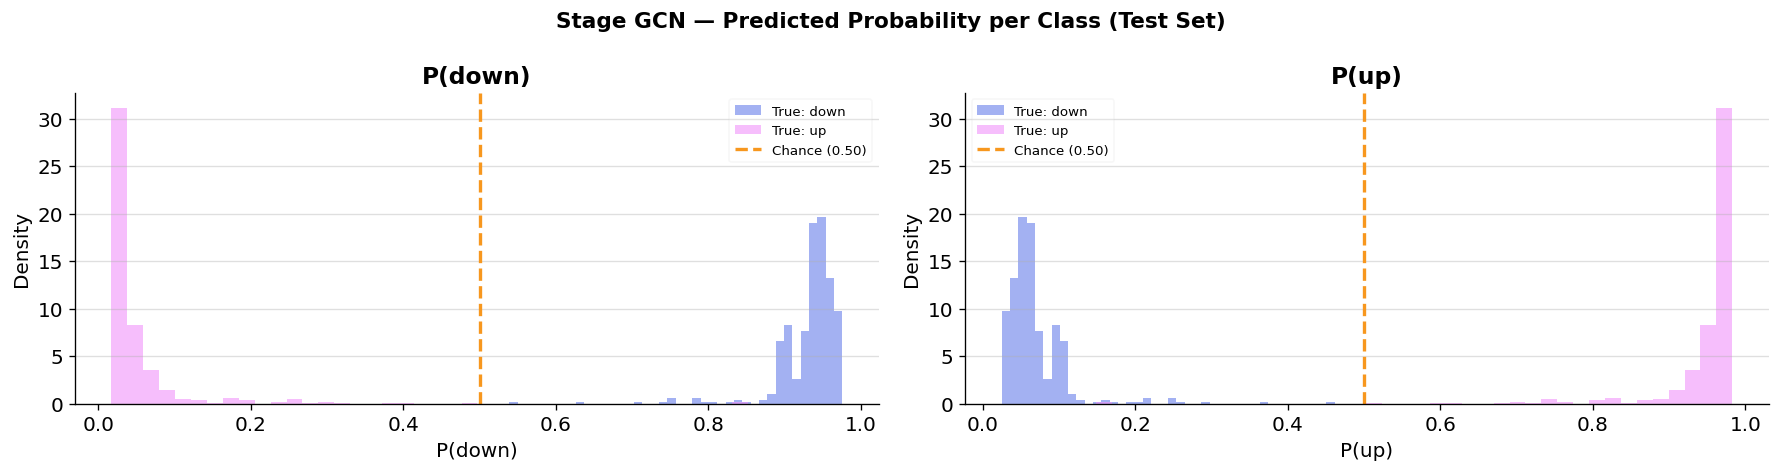

Saved: eval_stage_04_prob_distributions.png


In [25]:
# ── Per-class probability distributions (stage) ───────────────────────────
row_colors = [C1, C2, C3]

fig, axes = plt.subplots(1, N_STAGE_CLASSES, figsize=(15, 4))
fig.suptitle("Stage GCN — Predicted Probability per Class (Test Set)",
             fontsize=13, fontweight="bold")

for cls_idx in range(N_STAGE_CLASSES):
    ax = axes[cls_idx]
    for true_cls, color in enumerate(row_colors[:N_STAGE_CLASSES]):
        mask = stage_true == true_cls
        ax.hist(stage_probs[mask, cls_idx], bins=40, alpha=0.6,
                color=color, label=f"True: {stage_le.classes_[true_cls]}",
                edgecolor="none", density=True)
    ax.axvline(1/N_STAGE_CLASSES, color="#f7971e", lw=2, ls="--",
               label=f"Chance ({1/N_STAGE_CLASSES:.2f})")
    ax.set_xlabel(f"P({stage_le.classes_[cls_idx]})")
    ax.set_ylabel("Density")
    ax.set_title(f"P({stage_le.classes_[cls_idx]})", fontweight="bold")
    ax.legend(fontsize=8, framealpha=0.15)
    ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("eval_stage_04_prob_distributions.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_stage_04_prob_distributions.png")


In [26]:
# ── Save Stage model artifacts ────────────────────────────────────────────
torch.save(stage_model.state_dict(), "squat_stage_gcn.pth")
print("✅  Saved: squat_stage_gcn.pth")

with open("squat_stage_gcn_scaler.pkl", "wb") as f:
    pickle.dump(stage_scaler, f)
print("✅  Saved: squat_stage_gcn_scaler.pkl")

with open("squat_stage_gcn_label_encoder.pkl", "wb") as f:
    pickle.dump(stage_le, f)
print("✅  Saved: squat_stage_gcn_label_encoder.pkl")

print()
print("Stage label encoding:", dict(zip(stage_le.classes_, stage_le.transform(stage_le.classes_))))
print("Files needed for inference: squat_stage_gcn.pth  +  squat_stage_gcn_scaler.pkl")


✅  Saved: squat_stage_gcn.pth
✅  Saved: squat_stage_gcn_scaler.pkl
✅  Saved: squat_stage_gcn_label_encoder.pkl

Stage label encoding: {'down': np.int64(0), 'up': np.int64(1)}
Files needed for inference: squat_stage_gcn.pth  +  squat_stage_gcn_scaler.pkl


---
## 4. Results Summary


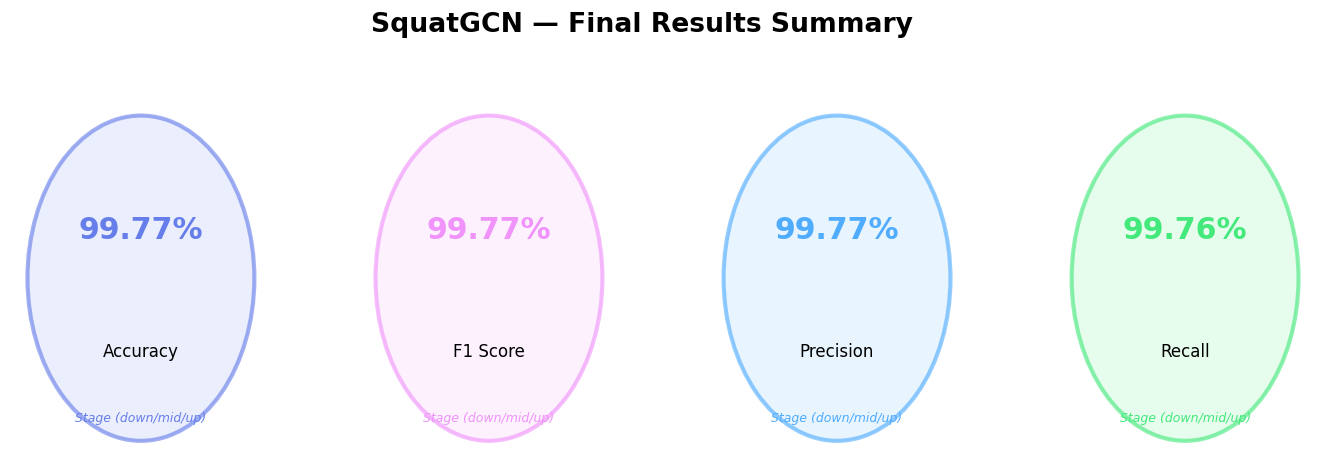

Saved: eval_combined_summary.png

  Metric          Stage (d/m/u)
---------------------------------------------
  Accuracy               99.77%
  F1 Score               99.77%
  Precision              99.77%
  Recall                 99.76%


In [27]:
# ── Final results summary dashboard ──────────────────────────────────────
metric_names  = ["Accuracy", "F1 Score", "Precision", "Recall"]
accent_colors = [C1, C2, C3, C4]

fig = plt.figure(figsize=(14, 4))
fig.suptitle("SquatGCN — Final Results Summary",
             fontsize=16, fontweight="bold", y=1.05)

gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

for col, (metric, color) in enumerate(zip(metric_names, accent_colors)):
    ax = fig.add_subplot(gs[0, col])
    val = stage_metrics[metric]
    ax.add_patch(plt.Circle((0.5, 0.5), 0.44, color=color, alpha=0.13))
    ax.add_patch(plt.Circle((0.5, 0.5), 0.44, fill=False,
                            edgecolor=color, linewidth=2.5, alpha=0.6))
    ax.text(0.5, 0.63, f"{val*100:.2f}%",
            ha="center", va="center", fontsize=18,
            fontweight="bold", color=color)
    ax.text(0.5, 0.30, metric,
            ha="center", va="center", fontsize=10)
    ax.text(0.5, 0.12, "Stage (down/mid/up)",
            ha="center", va="center", fontsize=7.5,
            color=color, fontstyle="italic")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

plt.savefig("eval_combined_summary.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_combined_summary.png")

print("\n" + "="*45)
print(f"  {'Metric':14s}  {'Stage (d/m/u)':>13}")
print("-"*45)
for m in metric_names:
    print(f"  {m:14s}  {stage_metrics[m]*100:>12.2f}%")
print("="*45)


In [28]:
# ── Summary of all saved files ────────────────────────────────────────────
import os

saved_files = [
    "squat_stage_gcn.pth",
    "squat_stage_gcn_scaler.pkl",
    "squat_stage_gcn_label_encoder.pkl",
]

print("── Saved model files ──────────────────────────────────────")
for fname in saved_files:
    exists = os.path.exists(fname)
    size   = os.path.getsize(fname) if exists else 0
    status = "✅" if exists else "❌ (not found — run training first)"
    print(f"  {status}  {fname:45s}  {size/1024:.1f} KB" if exists else f"  {status}  {fname}")

print()
print("── Saved figures ──────────────────────────────────────────")
figs = sorted([f for f in os.listdir(".") if f.endswith(".png")])
for f in figs:
    size = os.path.getsize(f)
    print(f"  📊  {f:50s}  {size/1024:.0f} KB")


── Saved model files ──────────────────────────────────────
  ✅  squat_stage_gcn.pth                            214.7 KB
  ✅  squat_stage_gcn_scaler.pkl                     1.3 KB
  ✅  squat_stage_gcn_label_encoder.pkl              0.2 KB

── Saved figures ──────────────────────────────────────────
  📊  eval_combined_summary.png                           112 KB
  📊  eval_stage_01_training_curves.png                   95 KB
  📊  eval_stage_02_confusion_matrix.png                  53 KB
  📊  eval_stage_03_per_class_metrics.png                 42 KB
  📊  eval_stage_04_prob_distributions.png                50 KB
  📊  fig_01_squat_pose_graph.png                         74 KB
  📊  fig_02_stage_class_distribution.png                 49 KB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')